### PoW

In [2]:
import numpy as np

embedding_matrix_pow = np.load('pow/embedding_matrix.npy', allow_pickle=True)
embedding_matrix_pow.shape

(296251, 64)

In [3]:
import pickle

with open('pow/ids.pkl', 'rb') as ids_bin:
    ids_pow = pickle.loads(ids_bin.read())

In [2]:
import pandas as pd

df_pow = pd.read_csv('pow/hdbscan_custom.csv')
df_pow

,node_ids,hdbscan
0,0x5747912c16d73510e35622c39bcfbe774cbff574,-1
1,0x823c122f6aae5e8b8fc93bd4ca6a81c6262665f0,-1
2,0xa31f8e36e716ea2adec26b33bcd3e7e9e335ee80,-1
3,0x10e995def8f4fb6d4d5adc37b1974941c384b743,3536
4,0x9f7fffcc688a0d61ddfc9750d3db5bdc77bf1344,1129
...,...,...
296246,0x3e8d9e2f56a4889b7d758c2e3c45f9508b32362b,-1
296247,0x5d9c04e77eb172a6546b0b79bd7e109871a4167a,1402
296248,0xf30accd666f2d040d19b813b33a8f99377ddb829,-1
296249,0x1eecd793c1b299e3cf88ed779fbbac0797480927,-1


In [15]:
import umap

embeddings_reduced_pow = umap.UMAP(n_components=2, low_memory=True).fit(embedding_matrix_pow)

/Users/mvbattan/Library/Caches/pypoetry/virtualenvs/pow_a_pos-zip6Mt8u-py3.9/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-07-05 20:06:50.272351: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


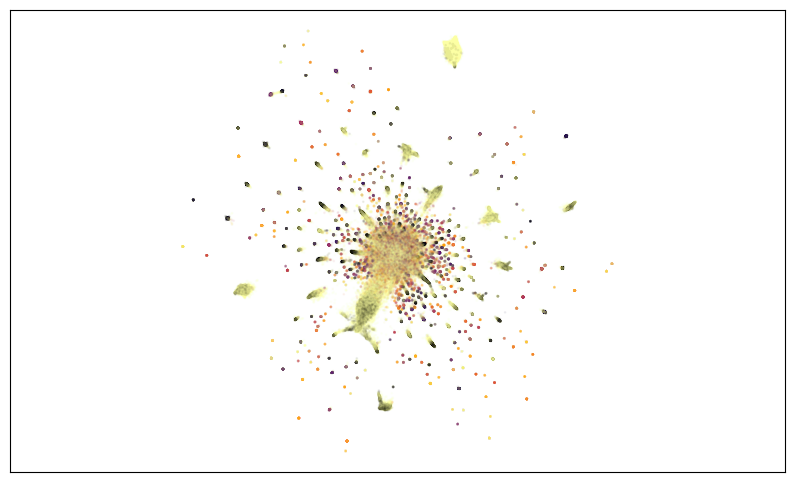

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    embeddings_reduced_pow.embedding_[:, 0],
    embeddings_reduced_pow.embedding_[:, 1],
    alpha=0.05,
    c=np.max(df_pow.hdbscan.values) - df_pow.hdbscan.values,
    cmap='inferno',
    s=1
)
plt.xticks([])
plt.yticks([])
plt.gca().set_aspect('equal', 'datalim')
plt.savefig('hdbscan_umap_pow.png')

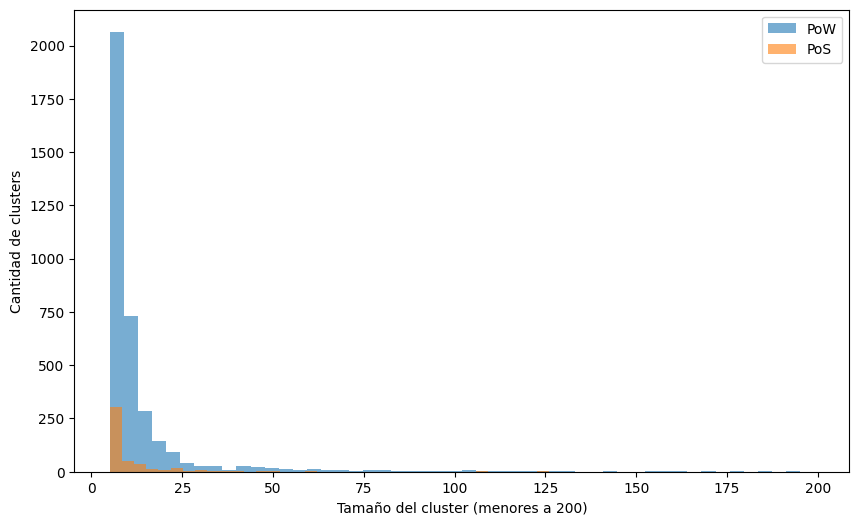

In [256]:
counts_pow = df_pow.hdbscan.value_counts()
counts_pos = df_pos.hdbscan.value_counts()

N = 200

plt.figure(figsize=(10, 6))
plt.hist(counts_pow[counts_pow < N].values, bins=50, alpha=0.6)
plt.hist(counts_pos[counts_pos < N].values, bins=50, alpha=0.6)
plt.legend(['PoW', 'PoS'])
plt.xlabel(f'Tamaño del cluster (menores a {N})')
plt.ylabel('Cantidad de clusters')
plt.show()

In [272]:
len(counts_pow)

3698

In [278]:
max(counts_pow)

197142

In [300]:
counts_pow[0:10] / 296251

hdbscan
-1       0.665456
 3694    0.032422
 3681    0.010339
 3666    0.006052
 3641    0.005954
 3647    0.005316
 3643    0.005222
 3695    0.005057
 3433    0.005036
 3689    0.004483
Name: count, dtype: float64

In [273]:
len(counts_pos)

480

In [301]:
counts_pos[0:10] / 265440

hdbscan
 478    0.822698
-1      0.145992
 68     0.003613
 283    0.002155
 381    0.001601
 105    0.001028
 468    0.000652
 45     0.000550
 259    0.000471
 423    0.000463
Name: count, dtype: float64

In [290]:
df_pow[df_pow.hdbscan != -1].hdbscan

3         3536
4         1129
5         1191
6         3694
7         1219
          ... 
296240    3647
296241    3666
296243    2091
296247    1402
296250    1461
Name: hdbscan, Length: 99109, dtype: int64

In [293]:
from scipy import stats
stats.hmean(df_pow[df_pow.hdbscan != -1].hdbscan.value_counts())

8.030394487762964

In [295]:
np.mean(df_pow[df_pow.hdbscan != -1].hdbscan.value_counts())

26.80795239383284

In [297]:
np.std(df_pow[df_pow.hdbscan != -1].hdbscan.value_counts())

191.56393038051087

In [294]:
stats.hmean(df_pos[df_pos.hdbscan != -1].hdbscan.value_counts())

7.419005054637549

In [296]:
np.mean(df_pos[df_pos.hdbscan != -1].hdbscan.value_counts())

473.2526096033403

In [298]:
np.std(df_pos[df_pos.hdbscan != -1].hdbscan.value_counts())

9966.85244532482

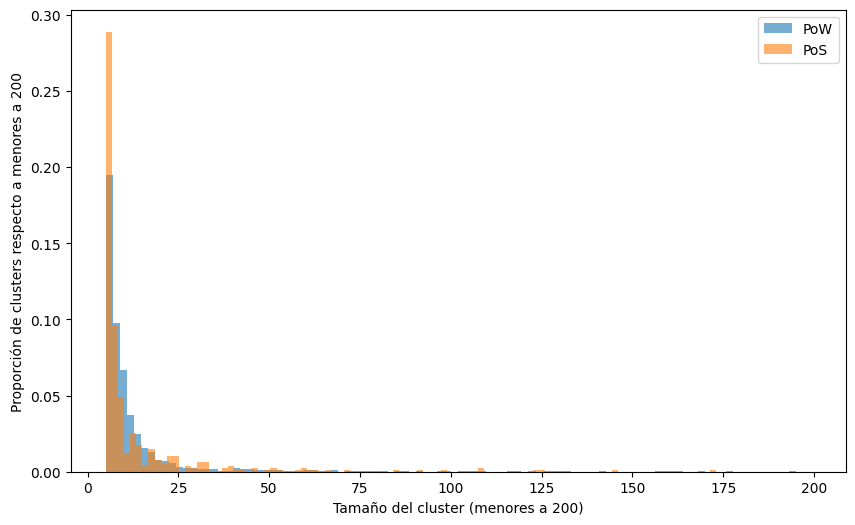

In [274]:
N = 200

plt.figure(figsize=(10, 6))
plt.hist(counts_pow[counts_pow < N].values, bins=100, alpha=0.6, density=True)
plt.hist(counts_pos[counts_pos < N].values, bins=100, alpha=0.6, density=True)
plt.legend(['PoW', 'PoS'])
plt.xlabel(f'Tamaño del cluster (menores a {N})')
plt.ylabel(f'Proporción de clusters respecto a menores a {N}')
plt.show()

### PoS

In [7]:
embedding_matrix_pos = np.load('pos/embedding_matrix.npy', allow_pickle=True)

In [8]:
embedding_matrix_pos.shape

(265440, 16)

In [9]:
with open('pos/ids.pkl', 'rb') as ids_bin:
    ids_pos = pickle.loads(ids_bin.read())

In [3]:
df_pos = pd.read_csv('pos/hdbscan_custom_iter_pos.csv')
df_pos

,node_ids,hdbscan,hdbscan_merge_1,hdbscan_level_2,hdbscan_merge_2
0,0xcb56595776f88dc2e404ed9d7b45108002889518,478,478,11.0,489.0
1,0x035b893825205ed6fc90904e6a014970ba4bbe9f,-1,-1,11.0,-1.0
2,0x971a5a39181a322a7d26aedd362247b3f462b1f3,-1,-1,-1.0,-1.0
3,0xc53137d18b421e307a95868cff300d2d74ffba47,478,478,11.0,489.0
4,0x505106877afc209775c1eada687364f133ff86ab,478,478,11.0,489.0
...,...,...,...,...,...
265435,0x10f10248dd358ff18bc0fce5d128a1e2030b1626,198,198,NaN,198.0
265436,0x313507fae42b9abb3993ea67acfb14ef25381213,478,478,11.0,489.0
265437,0xe53be01d66948a134934e70882c0099f23f42dea,478,478,11.0,489.0
265438,0x85d065f60425f202defc285325824cbf367ef5fb,478,478,11.0,489.0


In [14]:
df_pos.hdbscan.value_counts()

hdbscan
 478    218377
-1       38752
 68        959
 283       572
 381       425
         ...  
 173         5
 310         5
 162         5
 175         5
 404         5
Name: count, Length: 480, dtype: int64

In [16]:
embeddings_reduced_pos = umap.UMAP(n_components=2, low_memory=True).fit(embedding_matrix_pos)

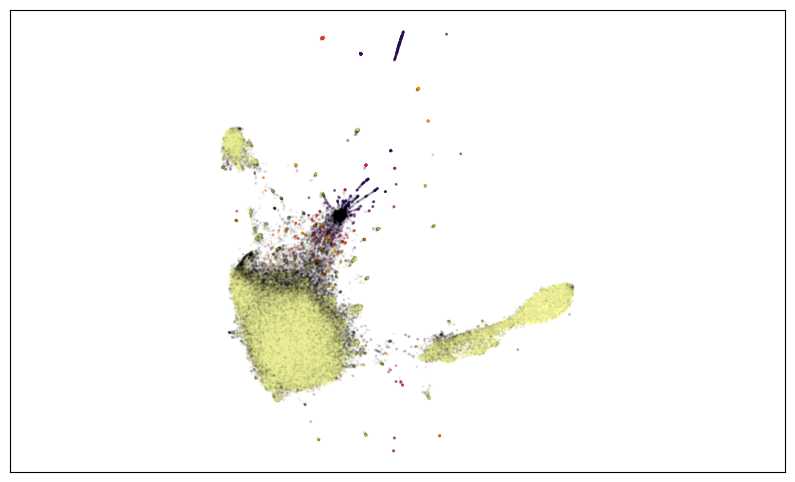

In [56]:
plt.figure(figsize=(10, 6))

plt.scatter(
    embeddings_reduced_pos.embedding_[:, 0],
    embeddings_reduced_pos.embedding_[:, 1],
    alpha=0.05,
    c=df_pos.hdbscan.values,
    cmap='inferno',
    s=1
)
plt.xticks([])
plt.yticks([])
plt.gca().set_aspect('equal', 'datalim')
plt.savefig('hdbscan_umap_pos.png')

### Comparison

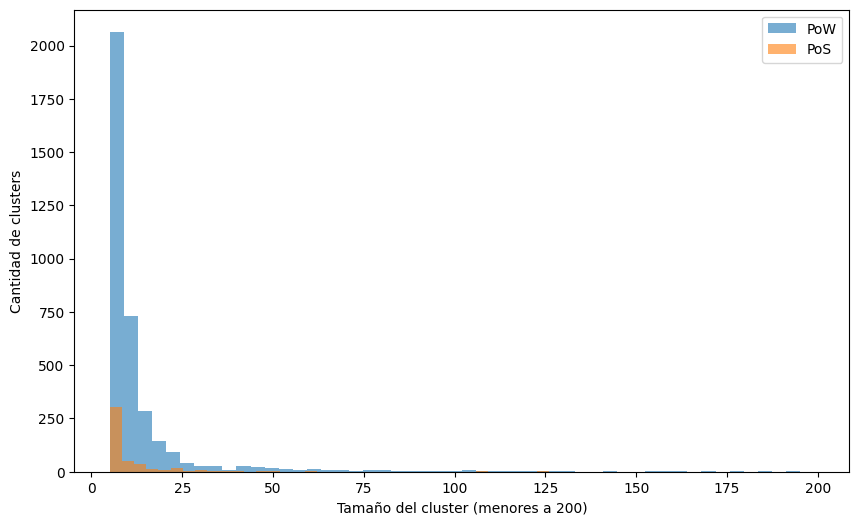

In [276]:
counts_pow = df_pow.hdbscan.value_counts()
counts_pos = df_pos.hdbscan.value_counts()

N = 200

plt.figure(figsize=(10, 6))
plt.hist(counts_pow[counts_pow < N].values, bins=50, alpha=0.6)
plt.hist(counts_pos[counts_pos < N].values, bins=50, alpha=0.6)
plt.legend(['PoW', 'PoS'])
plt.xlabel(f'Tamaño del cluster (menores a {N})')
plt.ylabel('Cantidad de clusters')
plt.savefig('cluster_count_comparison.png')
plt.show()

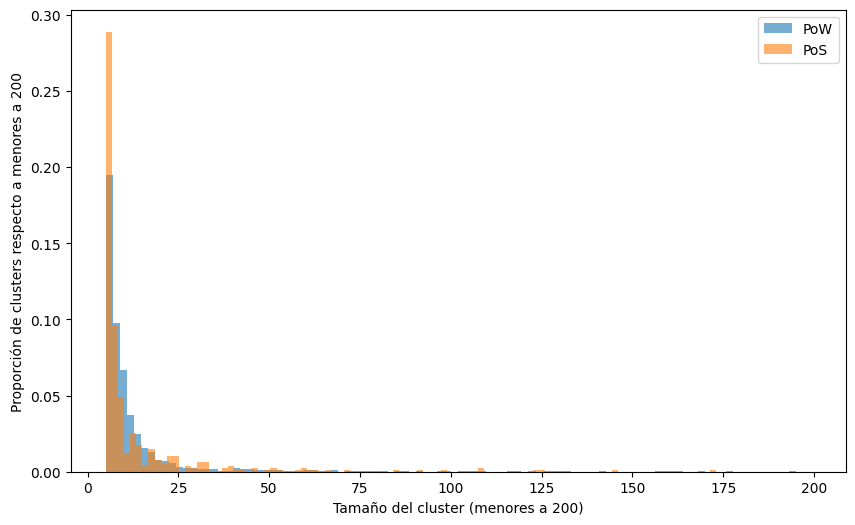

In [277]:
N = 200

plt.figure(figsize=(10, 6))
plt.hist(counts_pow[counts_pow < N].values, bins=100, alpha=0.6, density=True)
plt.hist(counts_pos[counts_pos < N].values, bins=100, alpha=0.6, density=True)
plt.legend(['PoW', 'PoS'])
plt.xlabel(f'Tamaño del cluster (menores a {N})')
plt.ylabel(f'Proporción de clusters respecto a menores a {N}')
plt.savefig('cluster_proportion_comparison.png')
plt.show()

<Axes: xlabel='count', ylabel='Density'>

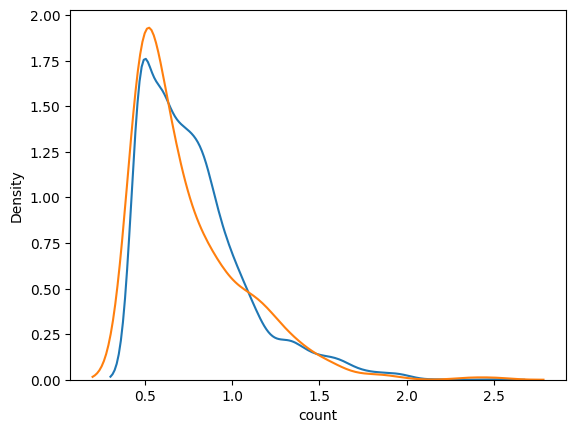

In [304]:
import seaborn as sns

sns.kdeplot(np.log(np.log(df_pow.hdbscan.value_counts())))
sns.kdeplot(np.log(np.log(df_pos.hdbscan.value_counts())))

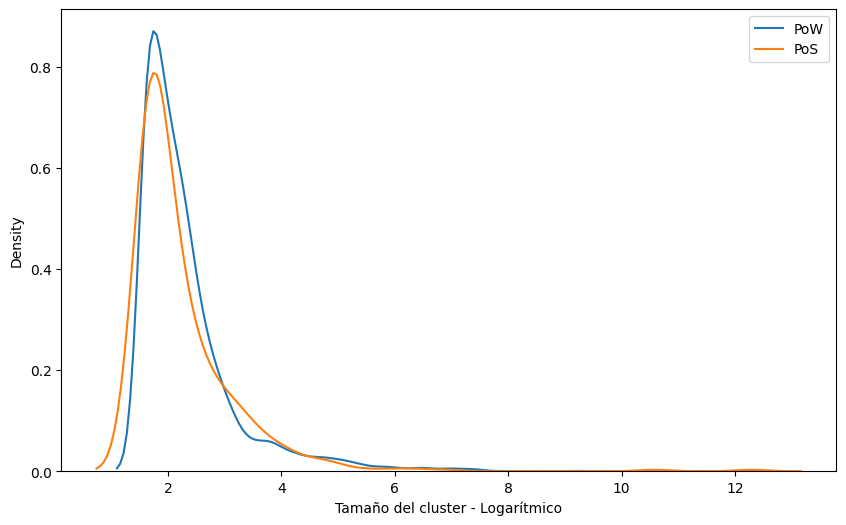

In [309]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(np.log(df_pow.hdbscan.value_counts()))
sns.kdeplot(np.log(df_pos.hdbscan.value_counts()))
plt.xlabel('Tamaño del cluster - Logarítmico')
plt.legend(['PoW', 'PoS'])
plt.show()

In [312]:
np.log(7.38905609893065)

2.0

In [36]:
len(ids_pos)

265440

In [37]:
len(ids_pow)

296251

In [39]:
ids_intersect = set(ids_pos.keys()).intersection(set(ids_pow.keys()))
len(ids_intersect)

8503

In [59]:
df_pos[df_pos.node_ids.isin(ids_intersect)].dtypes

node_ids            object
hdbscan              int64
hdbscan_merge_1      int64
hdbscan_level_2    float64
hdbscan_merge_2    float64
dtype: object

In [60]:
df_pow[df_pow.node_ids.isin(ids_intersect)].dtypes

node_ids    object
hdbscan      int64
dtype: object

In [64]:
df_pos_intersect = df_pos[df_pos.node_ids.isin(ids_intersect)].sort_values(by='node_ids').reset_index(drop=True)
df_pos_intersect

,node_ids,hdbscan,hdbscan_merge_1,hdbscan_level_2,hdbscan_merge_2
0,0x0000000000007f150bd6f54c40a34d7c3d5e9f56,-1,-1,11.0,-1.0
1,0x00000000003b3cc22af3ae1eac0440bcee416b40,478,478,11.0,489.0
2,0x00000000006c3852cbef3e08e8df289169ede581,478,478,11.0,489.0
3,0x000000000dfde7deaf24138722987c9a6991e2d4,478,478,11.0,489.0
4,0x00000000219ab540356cbb839cbe05303d7705fa,283,283,NaN,283.0
...,...,...,...,...,...
8498,0xfff33c415b261f65fb00f96cb0d00a56f4b36e2c,478,478,11.0,489.0
8499,0xfff5a8f200abb96cbaccaf90263268fa4260ae81,478,478,11.0,489.0
8500,0xfffa84476428be3370be2802b6e0fad24d9fe833,478,478,11.0,489.0
8501,0xfffceb755439ac0144783170239a82004c066daf,-1,-1,11.0,-1.0


In [65]:
df_pow_intersect = df_pow[df_pow.node_ids.isin(ids_intersect)].sort_values(by='node_ids').reset_index(drop=True)
df_pow_intersect

,node_ids,hdbscan
0,0x0000000000007f150bd6f54c40a34d7c3d5e9f56,3529
1,0x00000000003b3cc22af3ae1eac0440bcee416b40,3063
2,0x00000000006c3852cbef3e08e8df289169ede581,3694
3,0x000000000dfde7deaf24138722987c9a6991e2d4,2725
4,0x00000000219ab540356cbb839cbe05303d7705fa,1440
...,...,...
8498,0xfff33c415b261f65fb00f96cb0d00a56f4b36e2c,-1
8499,0xfff5a8f200abb96cbaccaf90263268fa4260ae81,-1
8500,0xfffa84476428be3370be2802b6e0fad24d9fe833,2191
8501,0xfffceb755439ac0144783170239a82004c066daf,-1


In [66]:
df_pos_intersect['hdbscan_old'] = df_pow_intersect['hdbscan']

In [67]:
df_pos_intersect['idx_pos'] = df_pos_intersect['node_ids'].apply(lambda x: ids_pos[x])
df_pos_intersect['idx_pow'] = df_pos_intersect['node_ids'].apply(lambda x: ids_pow[x])

In [139]:
len(df_pos_intersect) / len(df_pos)

0.03203360458107293

In [140]:
len(df_pos_intersect) / len(df_pow)

0.02870201282020989

In [68]:
df_pos_intersect

,node_ids,hdbscan,hdbscan_merge_1,hdbscan_level_2,hdbscan_merge_2,hdbscan_old,idx_pos,idx_pow
0,0x0000000000007f150bd6f54c40a34d7c3d5e9f56,-1,-1,11.0,-1.0,3529,4101,282838
1,0x00000000003b3cc22af3ae1eac0440bcee416b40,478,478,11.0,489.0,3063,218432,121488
2,0x00000000006c3852cbef3e08e8df289169ede581,478,478,11.0,489.0,3694,150502,58348
3,0x000000000dfde7deaf24138722987c9a6991e2d4,478,478,11.0,489.0,2725,262981,180729
4,0x00000000219ab540356cbb839cbe05303d7705fa,283,283,NaN,283.0,1440,36527,294313
...,...,...,...,...,...,...,...,...
8498,0xfff33c415b261f65fb00f96cb0d00a56f4b36e2c,478,478,11.0,489.0,-1,126613,270834
8499,0xfff5a8f200abb96cbaccaf90263268fa4260ae81,478,478,11.0,489.0,-1,29941,157507
8500,0xfffa84476428be3370be2802b6e0fad24d9fe833,478,478,11.0,489.0,2191,150086,248922
8501,0xfffceb755439ac0144783170239a82004c066daf,-1,-1,11.0,-1.0,-1,26440,195756


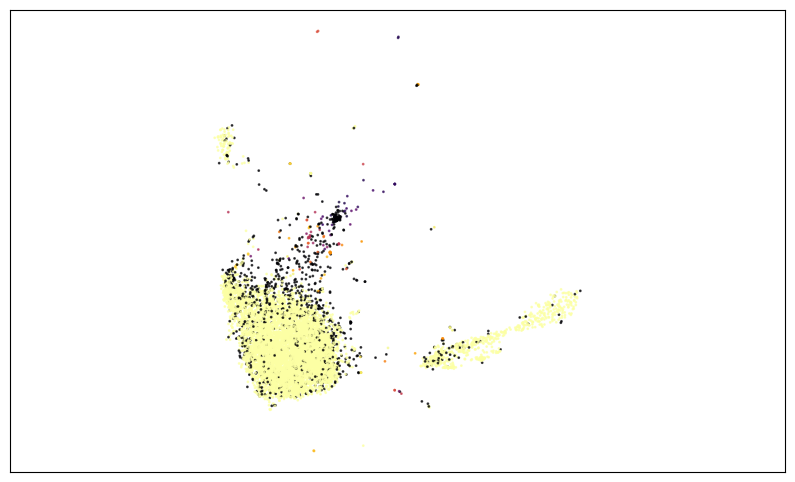

In [204]:
plt.figure(figsize=(10, 6))

plt.scatter(
    embeddings_reduced_pos.embedding_[df_pos_intersect['idx_pos']][:, 0],
    embeddings_reduced_pos.embedding_[df_pos_intersect['idx_pos']][:, 1],
    c=df_pos_intersect.hdbscan.values,
    cmap='inferno',
    alpha=0.7,
    s=1
)
plt.xticks([])
plt.yticks([])
plt.gca().set_aspect('equal', 'datalim')
plt.savefig('hdbscan_umap_intersect_pos.png')
plt.show()

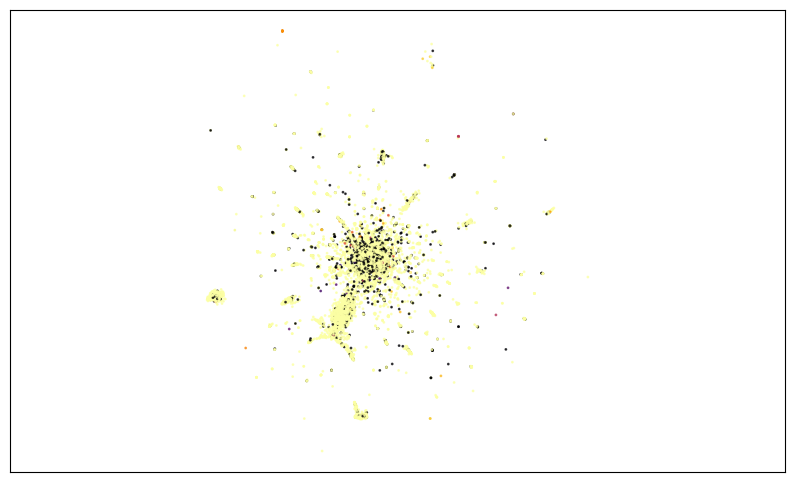

In [205]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    embeddings_reduced_pow.embedding_[df_pos_intersect['idx_pow']][:, 0],
    embeddings_reduced_pow.embedding_[df_pos_intersect['idx_pow']][:, 1],
    c=df_pos_intersect.hdbscan.values,
    alpha=0.7,
    cmap='inferno',
    s=1
)
plt.xticks([])
plt.yticks([])
plt.gca().set_aspect('equal', 'datalim')
plt.savefig('hdbscan_umap_intersect_pow.png')
plt.show()